In [1]:
import keras
import datasets
import keras_hub
import transformers
import numpy as np
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt

2025-10-06 23:20:16.925469: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-06 23:20:16.932452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759756816.941398  290514 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759756816.944148  290514 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759756816.950973  290514 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [3]:
train = datasets.load_dataset('wangrongsheng/ag_news', split='train')
test  = datasets.load_dataset('wangrongsheng/ag_news', split='test')

In [4]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')

In [5]:
tokenizer.pad_token = tokenizer.eos_token

In [6]:
def get_name(pref: str | None, suf: str, sep: str = '_') -> str | None:
    return pref and pref + sep + suf

In [7]:
def multihead_attention(
    q: keras.KerasTensor, 
    k: keras.KerasTensor, 
    v: keras.KerasTensor,
    n_head: int, 
    head_dim: int,
    mask: keras.KerasTensor | None = None, # B, L
    name: str | None = None,
    use_custom_attention: bool = True
) -> keras.KerasTensor:
    e = v.shape[-1]

    # xs = []
    # for i in range(n_head):
    #     head_name = get_name(name, f"head_{i + 1}")
        
    #     q_proj = keras.layers.Dense(head_dim, use_bias=False, name=get_name(head_name, "q_projection"))(q) # Q x D
    #     k_proj = keras.layers.Dense(head_dim, use_bias=False, name=get_name(head_name, "k_projection"))(k) # L x D
    #     v_proj = keras.layers.Dense(head_dim, use_bias=False, name=get_name(head_name, "v_projection"))(v)
    
    #     k_proj = keras.layers.Permute((2, 1), name=get_name(head_name, "k_transpose"))(k_proj) # D x L
    #     m = keras.layers.Dot((-1, -2), name=get_name(head_name, "q_k_dot"))((q_proj, k_proj)) # Q x L
    #     m_masked = keras.layers.Multiply(name=get_name(head_name, "masking"))((m, mask))
    #     m_softmax = keras.layers.Softmax(axis=-1, name=get_name(head_name, "q_k_softmax"))(m_masked) # Q x L
    
    #     x = keras.layers.Dot((-1, -2), name=get_name(head_name, "softmax_v_dot"))((m_softmax, v_proj)) # Q x D
    #     # o = keras.layers.Dense(e, use_bias=False, name=get_name(head_name, "output_projection"))(x) # Q x e
    #     xs.append(x)

    q_proj = keras.layers.EinsumDense("bqe,ehp->bqhp", output_shape=(None, n_head, head_dim), name=get_name(name, "q_projection"))(q)
    k_proj = keras.layers.EinsumDense("bke,ehp->bkhp", output_shape=(None, n_head, head_dim), name=get_name(name, "k_projection"))(k)
    v_proj = keras.layers.EinsumDense("bke,ehp->bkhp", output_shape=(None, n_head, head_dim), name=get_name(name, "v_projection"))(v)

    scale = 1 / np.sqrt(e)

    if mask is not None:
        mask = keras.ops.expand_dims(mask, (1, 2))

    if use_custom_attention:
        q_proj = keras.ops.multiply(q_proj, keras.ops.cast(scale, q_proj.dtype))

        m = keras.ops.einsum("bqhp,bkhp->bhqk", q_proj, k_proj)

        m = keras.layers.Softmax(axis=-1, name=get_name(name, "q_k_softmax"))(m, mask=mask)
        x = keras.ops.einsum("bhqk,bkhp->bqhp", m, v_proj)
        
    else:
        x = keras.ops.dot_product_attention(
            q_proj,
            k_proj,
            v_proj,
            bias=None,
            mask=keras.ops.cast(mask, 'bool'),
            scale=scale,
            is_causal=False,
            flash_attention=False
        )

    o = keras.layers.EinsumDense("bqhp,hpe->bqe", output_shape=(None, e), name=get_name(name, "output_projection"))(x)
    
    return o

In [8]:
def get_model(
    vocab_size: int,
    l: int,
    embedding_dim: int,
    n_head: int,
    head_dim: int,
    ff_dim: int,
    n_blocks: int,
    n_classses: int,
    use_cls: bool = True,
    name: str | None = None,
    use_custom_attention: bool = True
) -> keras.Model:
    inputs = x = keras.Input((None,), dtype="int32", name=get_name(name, "input"))
    mask = keras.Input((None, ), name=get_name(name, "mask_input"))
    x = keras_hub.layers.TokenAndPositionEmbedding(
        vocab_size, l, embedding_dim, name=get_name(name, "embedding")
    )(x)

    for i in range(n_blocks):
        block_name = get_name(name, f"block_{i + 1}")
        x_attention = multihead_attention(x, x, x, n_head, head_dim, name=get_name(block_name, "attention"), mask=mask, use_custom_attention=use_custom_attention)
        # x_attention = keras.layers.MultiHeadAttention(n_head, head_dim, name=get_name(block_name, "attention"))(x, x, attention_mask=mask)
        x = keras.layers.Add(name=get_name(block_name, "residual_1"))((x, x_attention))
        x = keras.layers.LayerNormalization(name=get_name(block_name, "norm_1"))(x)
        y = keras.layers.Dense(ff_dim, activation="swish", name=get_name(block_name, "dense_1"))(x)
        y = keras.layers.Dense(x.shape[-1], name=get_name(block_name, "dense_2"))(y)
        x = keras.layers.Add(name=get_name(block_name, "residual_2"))((x, y))
        x = keras.layers.LayerNormalization(name=get_name(block_name, "norm_2"))(x)

    if use_cls:
        x = x[:, 0, :]
    else:
        x = keras.layers.GlobalAveragePooling1D(name=get_name(name, "pooling"))(x)
    
    x = keras.layers.Dense(n_classses, name=get_name(name, "prediction"))(x)
    return keras.Model(inputs=(inputs, mask), outputs=x, name=name), x_attention

In [9]:
max_size = 128

In [10]:
robert, attention = get_model(
    vocab_size=len(tokenizer.get_vocab()) + 1,
    l=max_size + 1,
    embedding_dim=16,
    n_head=2,
    head_dim=8,
    ff_dim=64,
    n_blocks=4,
    n_classses=4,
    use_cls=True,
    name="robert",
    use_custom_attention=False
)   

I0000 00:00:1759756838.355977  290514 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19743 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
tokens_train = []
mask_train = []
for text in train['text']:
    tokenized = tokenizer(text, max_length=max_size, padding="max_length", truncation=True)
    tokens_train.append(tokenized['input_ids'])
    mask_train.append(tokenized['attention_mask'])

In [12]:
tokens_test = []
mask_test = []
for text in test['text']:
    tokenized = tokenizer(text, max_length=max_size, padding="max_length", truncation=True)
    tokens_test.append(tokenized['input_ids'])
    mask_test.append(tokenized['attention_mask'])

In [13]:
tokens_train = np.array(tokens_train)
tokens_test = np.array(tokens_test)
mask_train = np.array(mask_train)
mask_test = np.array(mask_test)

In [14]:
tokens_train = np.pad(tokens_train, ((0, 0), (1, 0)), constant_values=tokenizer.vocab_size)
tokens_test = np.pad(tokens_test, ((0, 0), (1, 0)), constant_values=tokenizer.vocab_size)
mask_train = np.pad(mask_train, ((0, 0), (1, 0)), constant_values=1)
mask_test = np.pad(mask_test, ((0, 0), (1, 0)), constant_values=1)

In [15]:
train_y = np.array(train["label"])
test_y = np.array(test["label"])

In [16]:
robert.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [18]:
robert.fit(
    (tokens_train, mask_train),
    train_y,
    batch_size=64,
    epochs=5,
    validation_data=((tokens_test, mask_test), test_y)
)

Epoch 1/5


I0000 00:00:1759756862.006352  290657 service.cc:152] XLA service 0x7fb5e402a1f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759756862.006364  290657 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090 Ti, Compute Capability 8.6
2025-10-06 23:21:02.090904: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1759756862.516243  290657 cuda_dnn.cc:529] Loaded cuDNN version 91100
2025-10-06 23:21:03.704199: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 344 bytes spill stores, 344 bytes spill loads

2025-10-06 23:21:03.797294: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7

  33/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2677 - loss: 1.5791

I0000 00:00:1759756866.427350  290657 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8886 - loss: 0.3133 - val_accuracy: 0.9201 - val_loss: 0.2365
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9483 - loss: 0.1502 - val_accuracy: 0.9166 - val_loss: 0.2413
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9652 - loss: 0.1016 - val_accuracy: 0.9125 - val_loss: 0.2904
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9754 - loss: 0.0710 - val_accuracy: 0.9120 - val_loss: 0.3293
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9817 - loss: 0.0513 - val_accuracy: 0.9107 - val_loss: 0.3686


938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


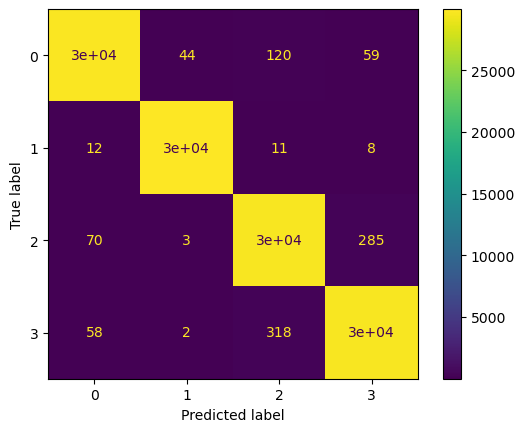

In [19]:
y_pred = robert.predict((tokens_train, mask_train), batch_size=128)
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(train_y, y_pred.argmax(axis=-1))

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


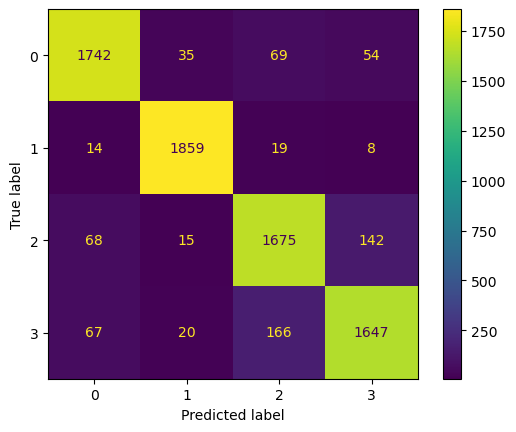

In [20]:
y_pred = robert.predict((tokens_test, mask_test), batch_size=128)
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(test_y, y_pred.argmax(axis=-1))